In [1]:
#Modelos lineales y correlación

In [5]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df_final = pd.read_csv("../Práctica 1/glp1_limpio.csv", parse_dates=['FECHA'])
df_final['ANIO'] = df_final['FECHA'].dt.year


In [3]:
#Volumen --> revenue 
#¿qué tan bien predice el volumen de unidades dispensadas el revenue generado?

In [ ]:
#resumen de los datos por año y sustancia para un análisis de correlación
resumen_anio_sustancia = df_final[df_final['ANIO'] != 2026].groupby(['ANIO', 'SUSTANCIA'])[['ACTUAL_COST', 'TOTAL_QUANTITY']].sum().reset_index()
print(resumen_anio_sustancia.shape)

(28, 4)


In [7]:
resultado_lineal = stats.linregress(resumen_anio_sustancia['TOTAL_QUANTITY'], resumen_anio_sustancia['ACTUAL_COST'])
print(resultado_lineal)

LinregressResult(slope=np.float64(4.582312322246047), intercept=np.float64(31008452.54650587), rvalue=np.float64(0.4169024704642379), pvalue=np.float64(0.027309961969823927), stderr=np.float64(1.9593143687624497), intercept_stderr=np.float64(11675776.932703562))


In [8]:
r_cuadrada = resultado_lineal.rvalue ** 2
print(r_cuadrada)

0.17380766987918475


In [9]:
#ya se que Tirzepatide se comporta diferente, así que vamos a ver si la correlación mejora si la quitamos del análisis
resumen_sin_tirze = resumen_anio_sustancia[resumen_anio_sustancia['SUSTANCIA'] != 'Tirzepatide']

resultado_sin_tirze = stats.linregress(resumen_sin_tirze['TOTAL_QUANTITY'], resumen_sin_tirze['ACTUAL_COST'])
r_cuadrada_sin_tirze = resultado_sin_tirze.rvalue ** 2

print(resultado_sin_tirze)
print('R² sin Tirzepatide:', r_cuadrada_sin_tirze)

LinregressResult(slope=np.float64(4.974225858970808), intercept=np.float64(20101824.865808517), rvalue=np.float64(0.7492403838329958), pvalue=np.float64(1.63399967615083e-05), stderr=np.float64(0.9168408412442801), intercept_stderr=np.float64(5769595.384809324))
R² sin Tirzepatide: 0.5613611527662149


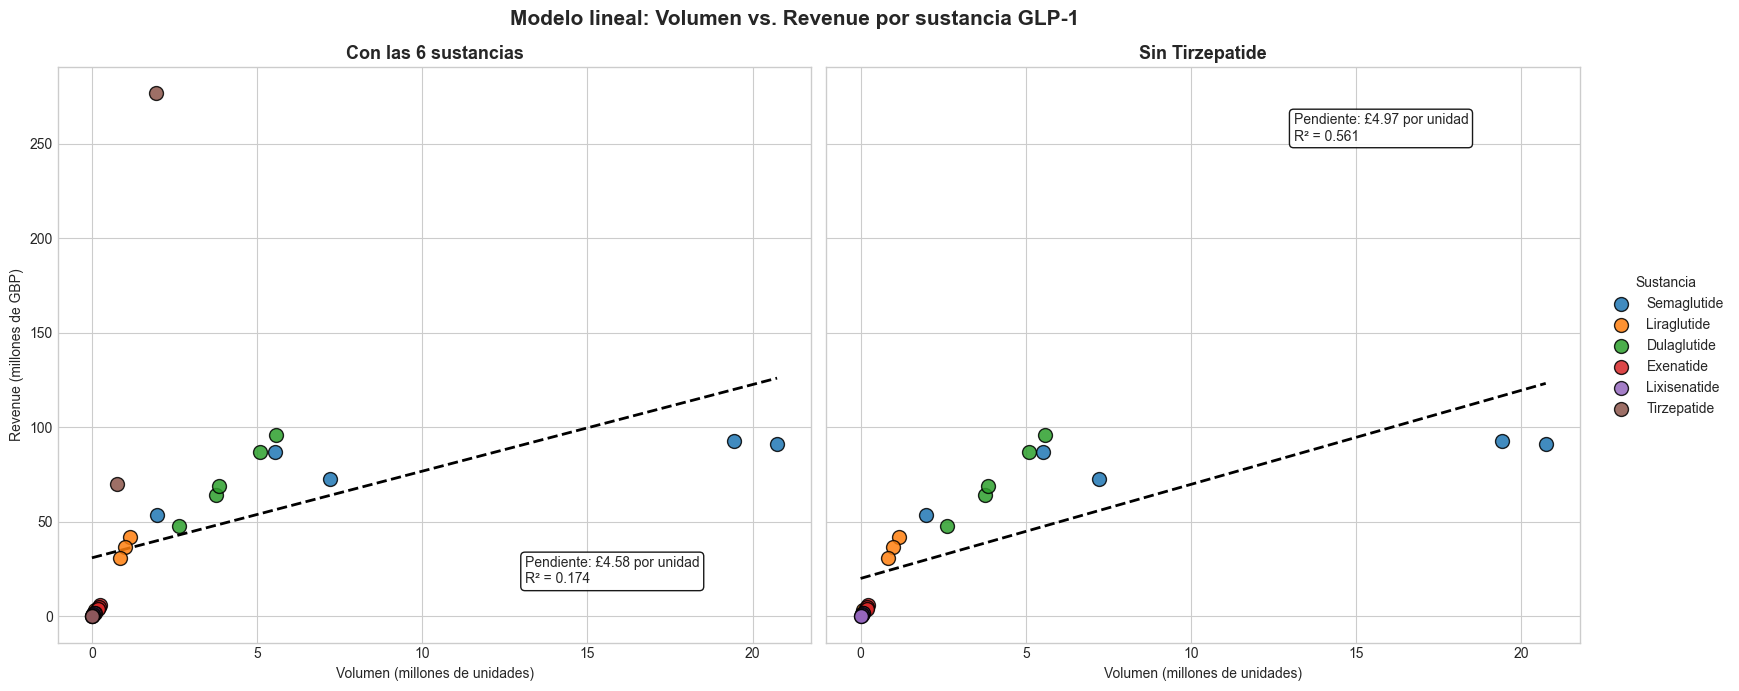

In [16]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for sustancia in sustancias_orden:
    datos = resumen_anio_sustancia[resumen_anio_sustancia['SUSTANCIA'] == sustancia]
    axes[0].scatter(datos['TOTAL_QUANTITY'] / 1_000_000, datos['ACTUAL_COST'] / 1_000_000, 
                     color=color_sustancia[sustancia], label=sustancia, s=100, 
                     edgecolors='black', alpha=0.85, zorder=3)

x_linea = resumen_anio_sustancia['TOTAL_QUANTITY'].sort_values()
y_linea = resultado_lineal.intercept + resultado_lineal.slope * x_linea
axes[0].plot(x_linea / 1_000_000, y_linea / 1_000_000, color='black', linestyle='--', linewidth=2, zorder=2)
axes[0].text(0.62, 0.15, f'Pendiente: £{resultado_lineal.slope:.2f} por unidad\nR² = {r_cuadrada:.3f}', 
             transform=axes[0].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
axes[0].set_title('Con las 6 sustancias', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Volumen (millones de unidades)')
axes[0].set_ylabel('Revenue (millones de GBP)')

for sustancia in sustancias_orden:
    if sustancia == 'Tirzepatide':
        continue
    datos = resumen_sin_tirze[resumen_sin_tirze['SUSTANCIA'] == sustancia]
    axes[1].scatter(datos['TOTAL_QUANTITY'] / 1_000_000, datos['ACTUAL_COST'] / 1_000_000, 
                     color=color_sustancia[sustancia], label=sustancia, s=100, 
                     edgecolors='black', alpha=0.85, zorder=3)

x_linea2 = resumen_sin_tirze['TOTAL_QUANTITY'].sort_values()
y_linea2 = resultado_sin_tirze.intercept + resultado_sin_tirze.slope * x_linea2
axes[1].plot(x_linea2 / 1_000_000, y_linea2 / 1_000_000, color='black', linestyle='--', linewidth=2, zorder=2)
axes[1].text(0.62, 0.92, f'Pendiente: £{resultado_sin_tirze.slope:.2f} por unidad\nR² = {r_cuadrada_sin_tirze:.3f}', 
             transform=axes[1].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
axes[1].set_title('Sin Tirzepatide', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Volumen (millones de unidades)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Sustancia')

fig.suptitle('Modelo lineal: Volumen vs. Revenue por sustancia GLP-1', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
#Modelo agrupando datos por mes y sustancia para ver si la correlación mejora al tener más puntos de datos
resumen_mes_sustancia = df_final.groupby(['FECHA', 'SUSTANCIA'])[['ACTUAL_COST', 'TOTAL_QUANTITY']].sum().reset_index()
print(resumen_mes_sustancia.shape)

(355, 4)


In [18]:
resultado_mensual = stats.linregress(resumen_mes_sustancia['TOTAL_QUANTITY'], resumen_mes_sustancia['ACTUAL_COST'])
r_cuadrada_mensual = resultado_mensual.rvalue ** 2

resumen_mes_sin_tirze = resumen_mes_sustancia[resumen_mes_sustancia['SUSTANCIA'] != 'Tirzepatide']
resultado_mensual_sin_tirze = stats.linregress(resumen_mes_sin_tirze['TOTAL_QUANTITY'], resumen_mes_sin_tirze['ACTUAL_COST'])
r_cuadrada_mensual_sin_tirze = resultado_mensual_sin_tirze.rvalue ** 2

print('Mensual, con las 6 sustancias — R²:', r_cuadrada_mensual)
print('Mensual, sin Tirzepatide — R²:', r_cuadrada_mensual_sin_tirze)

Mensual, con las 6 sustancias — R²: 0.0746368720298663
Mensual, sin Tirzepatide — R²: 0.5691215015805136


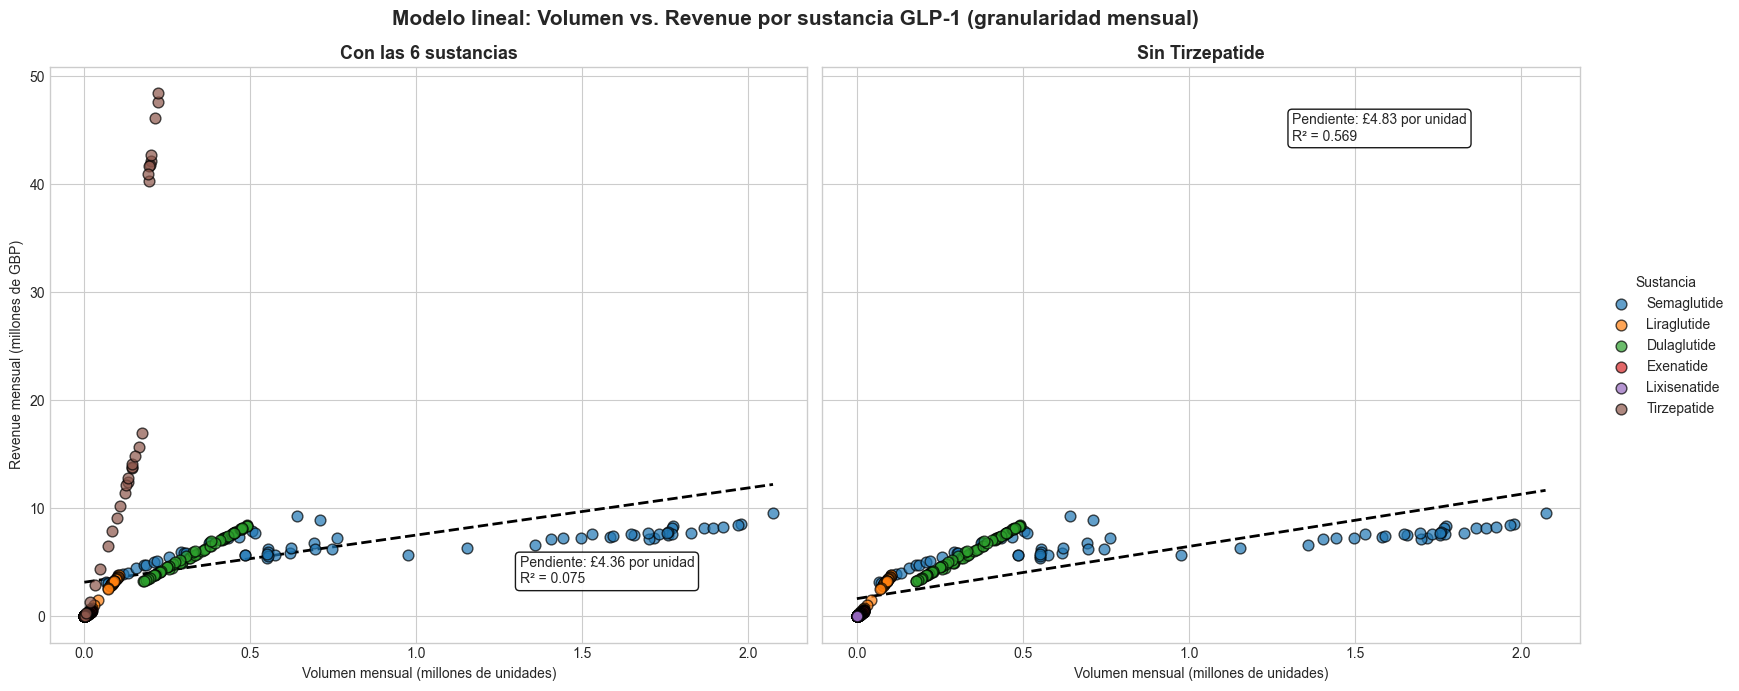

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for sustancia in sustancias_orden:
    datos = resumen_mes_sustancia[resumen_mes_sustancia['SUSTANCIA'] == sustancia]
    axes[0].scatter(datos['TOTAL_QUANTITY'] / 1_000_000, datos['ACTUAL_COST'] / 1_000_000, 
                     color=color_sustancia[sustancia], label=sustancia, s=60, 
                     edgecolors='black', alpha=0.7, zorder=3)

x_linea = resumen_mes_sustancia['TOTAL_QUANTITY'].sort_values()
y_linea = resultado_mensual.intercept + resultado_mensual.slope * x_linea
axes[0].plot(x_linea / 1_000_000, y_linea / 1_000_000, color='black', linestyle='--', linewidth=2, zorder=2)
axes[0].text(0.62, 0.15, f'Pendiente: £{resultado_mensual.slope:.2f} por unidad\nR² = {r_cuadrada_mensual:.3f}', 
             transform=axes[0].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
axes[0].set_title('Con las 6 sustancias', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Volumen mensual (millones de unidades)')
axes[0].set_ylabel('Revenue mensual (millones de GBP)')

for sustancia in sustancias_orden:
    if sustancia == 'Tirzepatide':
        continue
    datos = resumen_mes_sin_tirze[resumen_mes_sin_tirze['SUSTANCIA'] == sustancia]
    axes[1].scatter(datos['TOTAL_QUANTITY'] / 1_000_000, datos['ACTUAL_COST'] / 1_000_000, 
                     color=color_sustancia[sustancia], label=sustancia, s=60, 
                     edgecolors='black', alpha=0.7, zorder=3)

x_linea2 = resumen_mes_sin_tirze['TOTAL_QUANTITY'].sort_values()
y_linea2 = resultado_mensual_sin_tirze.intercept + resultado_mensual_sin_tirze.slope * x_linea2
axes[1].plot(x_linea2 / 1_000_000, y_linea2 / 1_000_000, color='black', linestyle='--', linewidth=2, zorder=2)
axes[1].text(0.62, 0.92, f'Pendiente: £{resultado_mensual_sin_tirze.slope:.2f} por unidad\nR² = {r_cuadrada_mensual_sin_tirze:.3f}', 
             transform=axes[1].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
axes[1].set_title('Sin Tirzepatide', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Volumen mensual (millones de unidades)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Sustancia')

fig.suptitle('Modelo lineal: Volumen vs. Revenue por sustancia GLP-1 (granularidad mensual)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
#verificar si cada sustancia tiene un comportamiento lineal similar al del conjunto de datos completo
resultados_por_sustancia = {}

for sustancia in sustancias_orden:
    datos = resumen_mes_sustancia[resumen_mes_sustancia['SUSTANCIA'] == sustancia]
    resultado = stats.linregress(datos['TOTAL_QUANTITY'], datos['ACTUAL_COST'])
    r2 = resultado.rvalue ** 2
    resultados_por_sustancia[sustancia] = {'slope': resultado.slope, 'r2': r2, 'n_puntos': len(datos)}

for sustancia, info in resultados_por_sustancia.items():
    print(f"{sustancia}: slope={info['slope']:.2f}, R²={info['r2']:.3f}, n={info['n_puntos']}")

Semaglutide: slope=1.64, R²=0.572, n=65
Liraglutide: slope=36.82, R²=1.000, n=65
Dulaglutide: slope=16.31, R²=0.996, n=65
Exenatide: slope=24.96, R²=0.954, n=65
Lixisenatide: slope=27.10, R²=1.000, n=60
Tirzepatide: slope=191.77, R²=0.817, n=35


In [21]:
#investigar por qué semaglutide tiene un R² tan bajo comparado con las otras sustancias
##precio por unidad mes a mes
semaglutide_mensual = resumen_mes_sustancia[resumen_mes_sustancia['SUSTANCIA'] == 'Semaglutide'].copy()
semaglutide_mensual['precio_unidad'] = semaglutide_mensual['ACTUAL_COST'] / semaglutide_mensual['TOTAL_QUANTITY']
print(semaglutide_mensual['precio_unidad'].describe())

count    65.000000
mean     12.575668
std      10.252160
min       4.235313
25%       4.611909
50%       9.801481
75%      17.413032
max      48.530737
Name: precio_unidad, dtype: float64


In [ ]:
#comparando con una sustancia con un R² alto, como dulaglutide
dulaglutide_mensual = resumen_mes_sustancia[resumen_mes_sustancia['SUSTANCIA'] == 'Dulaglutide'].copy()
dulaglutide_mensual['precio_unidad'] = dulaglutide_mensual['ACTUAL_COST'] / dulaglutide_mensual['TOTAL_QUANTITY']
print(dulaglutide_mensual['precio_unidad'].describe())

count    65.000000
mean     17.573142
std       0.538999
min      17.043718
25%      17.124535
50%      17.221779
75%      18.221300
max      18.240318
Name: precio_unidad, dtype: float64


In [23]:
#modelo 2 para descrbir la relaion entre el tiempo y el revenue, para ver si el revenue crece de manera lineal con el tiempo, o si hay un patrón diferente.
#se va a correr un modelo por sustancia  
resumen_mes_sustancia['MES_NUMERO'] = (resumen_mes_sustancia['FECHA'].dt.year - 2021) * 12 + resumen_mes_sustancia['FECHA'].dt.month
print(resumen_mes_sustancia[['FECHA', 'MES_NUMERO']].head())
print(resumen_mes_sustancia[['FECHA', 'MES_NUMERO']].tail())

       FECHA  MES_NUMERO
0 2021-01-01           1
1 2021-01-01           1
2 2021-01-01           1
3 2021-01-01           1
4 2021-01-01           1
         FECHA  MES_NUMERO
350 2026-05-01          65
351 2026-05-01          65
352 2026-05-01          65
353 2026-05-01          65
354 2026-05-01          65


In [25]:
crecimiento_por_sustancia = {}

for sustancia in sustancias_orden:
    datos = resumen_mes_sustancia[resumen_mes_sustancia['SUSTANCIA'] == sustancia]
    resultado = stats.linregress(datos['MES_NUMERO'], datos['ACTUAL_COST'])
    r2 = resultado.rvalue ** 2
    crecimiento_por_sustancia[sustancia] = {'slope': resultado.slope, 'r2': r2, 'n_puntos': len(datos)}

for sustancia, info in crecimiento_por_sustancia.items():
    print(f"{sustancia}: crecimiento=£{info['slope']:,.0f}/mes, R²={info['r2']:.3f}, n={info['n_puntos']}")

Semaglutide: crecimiento=£50,279/mes, R²=0.433, n=65
Liraglutide: crecimiento=£-73,931/mes, R²=0.849, n=65
Dulaglutide: crecimiento=£-43,772/mes, R²=0.253, n=65
Exenatide: crecimiento=£-7,294/mes, R²=0.797, n=65
Lixisenatide: crecimiento=£-2,977/mes, R²=0.951, n=60
Tirzepatide: crecimiento=£1,451,473/mes, R²=0.813, n=35


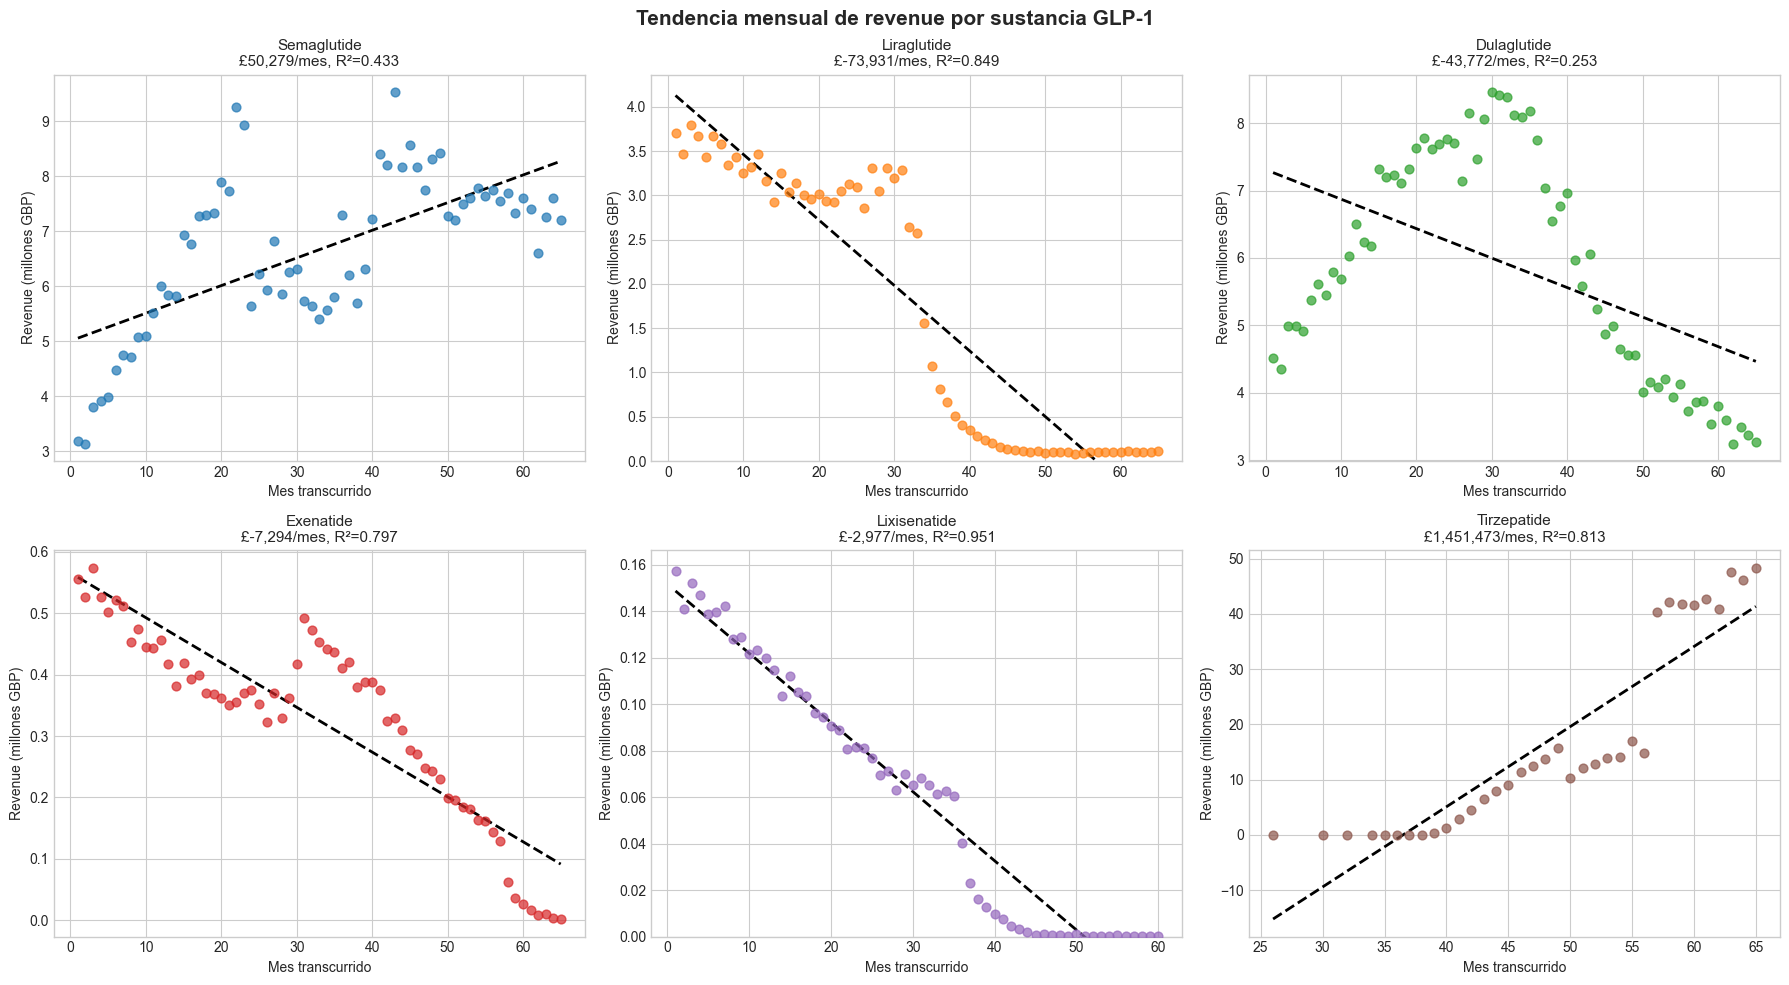

In [29]:
paleta = plt.cm.tab10.colors
sustancias_orden = ['Semaglutide', 'Liraglutide', 'Dulaglutide', 'Exenatide', 'Lixisenatide', 'Tirzepatide']
color_sustancia = dict(zip(sustancias_orden, paleta))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sustancia in enumerate(sustancias_orden):
    datos = resumen_mes_sustancia[resumen_mes_sustancia['SUSTANCIA'] == sustancia].sort_values('MES_NUMERO')
    axes[i].scatter(datos['MES_NUMERO'], datos['ACTUAL_COST'] / 1_000_000, 
                     color=color_sustancia[sustancia], s=40, alpha=0.7, zorder=3)
    
    info = crecimiento_por_sustancia[sustancia]
    x_linea = datos['MES_NUMERO']
    resultado_temp = stats.linregress(datos['MES_NUMERO'], datos['ACTUAL_COST'])
    y_linea = (resultado_temp.intercept + resultado_temp.slope * x_linea) / 1_000_000
    axes[i].plot(x_linea, y_linea, color='black', linestyle='--', linewidth=2, zorder=2)
    
    axes[i].set_title(f"{sustancia}\n£{info['slope']:,.0f}/mes, R²={info['r2']:.3f}", fontsize=11)
    axes[i].set_xlabel('Mes transcurrido')
    axes[i].set_ylabel('Revenue (millones GBP)')
axes[1].set_ylim(bottom=0)  # Liraglutide
axes[4].set_ylim(bottom=0)  # Lixisenatide
fig.suptitle('Tendencia mensual de revenue por sustancia GLP-1', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()